# Exercises XP Ninja: Airline Passenger Forecasting with RNNs

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

> **IMPORTANT: delete last row in the downloaded dataset "International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60"**

## What you will learn
- Preprocess and analyze a time series
- Build and train Simple RNN, LSTM, GRU
- Evaluate and compare models
- Visualize training history and predictions

## What you will create
- A predictive model for the number of international airline passengers

# Part 1: Data preparation

**As stated in the exercise**
Load the dataset, inspect it, drop rows with missing values, scale to a suitable range, and make supervised sequences using the past 6 months to predict the next month.

**PREFILLED just execute**
Imports, path, loader, and basic inspection helpers.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 50)

# Change this to your CSV path if needed
DATA_PATH = Path('./international-airline-passengers.csv')  # To-Do: change if your file is elsewhere

def load_air_passengers(csv_path: Path):
    df = pd.read_csv(csv_path, skiprows=1)
    # strip spaces in header
    df.columns = [str(c).strip() for c in df.columns]
    cols = list(df.columns)

    # try to detect by name
    date_col = next((c for c in cols if str(c).lower().startswith(("month","date"))), None)
    value_col = next((c for c in cols if str(c).lower().startswith(("pass","value"))), None)

    # fallback: assume 2-column file [date, value]
    if date_col is None or value_col is None:
        if len(cols) < 2:
            raise ValueError("Expected at least 2 columns [date, value].")
        date_col, value_col = cols[0], cols[1]

    # parse and clean
    df[date_col] = pd.to_datetime(df[date_col], errors="raise")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[value_col])
    df = df.rename(columns={date_col: "Date", value_col: "Passengers"})
    df = df.sort_values("Date").reset_index(drop=True)
    return df[["Date","Passengers"]]


df = load_air_passengers(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.tail())
display(df.describe())

Shape: (143, 2)


,Date,Passengers
0,1949-02-01,118
1,1949-03-01,132
2,1949-04-01,129
3,1949-05-01,121
4,1949-06-01,135


,Date,Passengers
138,1960-08-01,606
139,1960-09-01,508
140,1960-10-01,461
141,1960-11-01,390
142,1960-12-01,432


,Date,Passengers
count,143,143.000000
mean,1954-12-31 10:04:11.748251776,281.475524
min,1949-02-01 00:00:00,104.000000
25%,1952-01-16 12:00:00,180.500000
50%,1955-01-01 00:00:00,267.000000
75%,1957-12-16 12:00:00,361.000000
max,1960-12-01 00:00:00,622.000000
std,NaN,119.550851


**To-Do (code):** Drop rows with missing values then recheck that no NaNs remain.

In [20]:
# To-Do: handle missing values
df = df.dropna()
assert df.isna().sum().sum() == 0, 'There are still missing values'

**Learning point**
Scale before windowing for stable gradients. For univariate series a MinMax scaler to [0,1] is often sufficient. Keep the scaler to invert predictions later.

**PREFILLED just execute**
Scaling and sequence maker using past 6 months to predict month t+1. Chronological split into train and test.

In [21]:
def make_sequences(values_1d: np.ndarray, lookback: int = 6, horizon: int = 1):
    X, y = [], []
    for i in range(len(values_1d) - lookback - horizon + 1):
        X.append(values_1d[i:i+lookback])
        y.append(values_1d[i+lookback:i+lookback+horizon])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    # reshape to [samples, timesteps, features=1]
    return X.reshape(len(X), lookback, 1), y.reshape(len(y), horizon)

LOOKBACK = 6
HORIZON = 1

# Scale
scaler = MinMaxScaler(feature_range=(0,1))
series = df[['Passengers']].astype('float32')
series_scaled = scaler.fit_transform(series)

# Split by time 80-20
split_idx = int(len(series_scaled) * 0.8)
train_vals = series_scaled[:split_idx].ravel()
test_vals  = series_scaled[split_idx - LOOKBACK:].ravel()  # overlap LOOKBACK for continuity

X_train, y_train = make_sequences(train_vals, lookback=LOOKBACK, horizon=HORIZON)
X_test,  y_test  = make_sequences(test_vals,  lookback=LOOKBACK, horizon=HORIZON)
print({'X_train': X_train.shape, 'y_train': y_train.shape, 'X_test': X_test.shape, 'y_test': y_test.shape})

{'X_train': (108, 6, 1), 'y_train': (108, 1), 'X_test': (29, 6, 1), 'y_test': (29, 1)}


**To-Do (written):** Explain why we overlapped LOOKBACK points into the test split window.

Les points LOOKBACK sont superposés à la fenêtre de test afin de garantir que la première prédiction effectuée sur l'ensemble de test dispose de suffisamment de données précédentes (la fenêtre LOOKBACK) pour constituer sa séquence d'entrée. En prévision de séries temporelles, chaque prédiction repose sur une fenêtre d'observations passées. Sans cette superposition, le nombre initial de prédictions LOOKBACK dans l'ensemble de test serait insuffisant, car il manquerait de données historiques issues de l'ensemble d'entraînement, rendant ces prédictions impossibles ou nécessitant un traitement particulier.

![](./figs/1.gif)

# Part 2: Model building

**As stated in the exercise**
Build Simple RNN, LSTM, and GRU. Use Adam and MSE. Print summaries.

**PREFILLED just execute**
Keras imports and a helper to build each model.

In [23]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 757.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 159.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 109.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_simple_rnn(units=32, lookback=LOOKBACK, features=1):
    # To-Do: stack one or more SimpleRNN layers, end with Dense(HORIZON)
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.SimpleRNN(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(units=32, lookback=LOOKBACK, features=1):
    # To-Do: stack one or more LSTM layers, end with Dense(HORIZON)
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.LSTM(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(units=32, lookback=LOOKBACK, features=1):
    # To-Do: stack one or more GRU layers, end with Dense(HORIZON)
    model = models.Sequential([
        layers.Input(shape=(lookback, features)),
        layers.GRU(units, return_sequences=False),
        layers.Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print(tf.__version__)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


2.21.0


**To-Do (code):** Fill the model bodies above, then instantiate `model_rnn`, `model_lstm`, and `model_gru`. Call `summary()` for each.

In [25]:
# To-Do: build and summarize models
model_rnn  = build_simple_rnn(units=32)
model_lstm = build_lstm(units=32)
model_gru  = build_gru(units=32)
model_rnn.summary(); model_lstm.summary(); model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 3: Model training

**As stated in the exercise**
Train the three models. Use early stopping.

**PREFILLED just execute**
Callbacks and a helper to fit a model and return history.

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_model(model, X_tr, y_tr, X_te, y_te, epochs=100, batch=16):
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    h = model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=epochs,
        batch_size=batch,
        callbacks=[es, rl],
        verbose=2
    )
    return h

def plot_history(history, title='Training history'):
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(title)
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()

**To-Do (code):** Train each model for up to 100 epochs with early stopping. Plot histories using `plot_history`.

Epoch 1/100
7/7 - 1s - 137ms/step - loss: 0.2027 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 2/100
7/7 - 0s - 9ms/step - loss: 0.0291 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 3/100
7/7 - 0s - 9ms/step - loss: 0.0379 - val_loss: 0.0508 - learning_rate: 0.0010
Epoch 4/100
7/7 - 0s - 9ms/step - loss: 0.0190 - val_loss: 0.0913 - learning_rate: 0.0010
Epoch 5/100
7/7 - 0s - 9ms/step - loss: 0.0177 - val_loss: 0.1020 - learning_rate: 0.0010
Epoch 6/100
7/7 - 0s - 9ms/step - loss: 0.0160 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 7/100
7/7 - 0s - 9ms/step - loss: 0.0130 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 8/100
7/7 - 0s - 9ms/step - loss: 0.0130 - val_loss: 0.0490 - learning_rate: 5.0000e-04
Epoch 9/100
7/7 - 0s - 9ms/step - loss: 0.0124 - val_loss: 0.0498 - learning_rate: 5.0000e-04
Epoch 10/100
7/7 - 0s - 9ms/step - loss: 0.0120 - val_loss: 0.0533 - learning_rate: 5.0000e-04
Epoch 11/100
7/7 - 0s - 9ms/step - loss: 0.0116 - val_loss: 0.0511 - learning_rate: 5

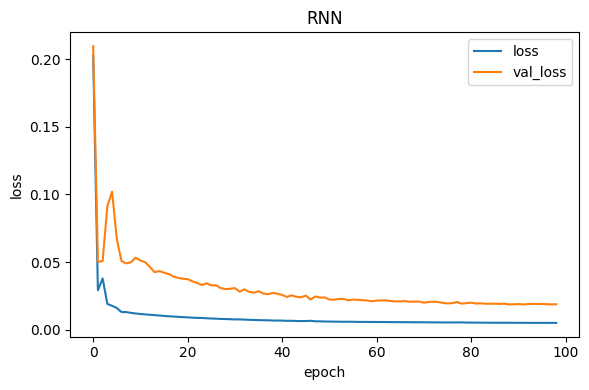

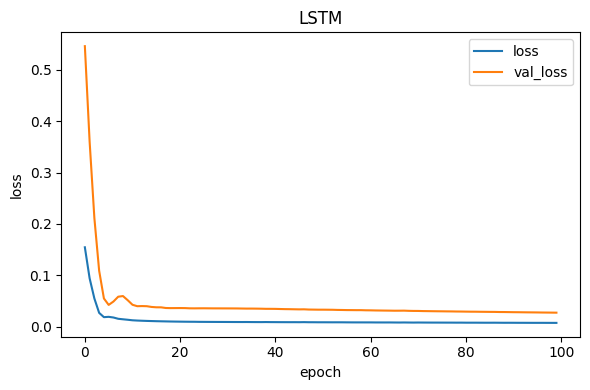

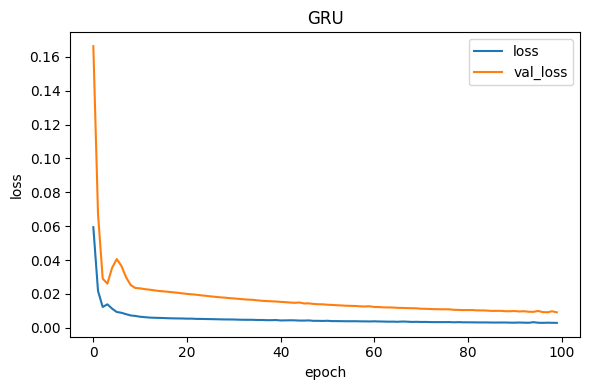

In [27]:
# To-Do: train and plot
h_rnn  = fit_model(model_rnn,  X_train, y_train, X_test, y_test, epochs=100, batch=16)
h_lstm = fit_model(model_lstm, X_train, y_train, X_test, y_test, epochs=100, batch=16)
h_gru  = fit_model(model_gru,  X_train, y_train, X_test, y_test, epochs=100, batch=16)
plot_history(h_rnn,  title='RNN')
plot_history(h_lstm, title='LSTM')
plot_history(h_gru,  title='GRU')

# Part 4: Visualizing training history

**As stated in the exercise**
Plot training and validation loss for each model and compare.

**To-Do (written):** Compare the learning curves. Which model converges faster and to a lower validation loss. Explain briefly.

From the learning curves, the RNN converges relatively quickly, with the training loss dropping sharply during the first few epochs and then decreasing gradually toward a very low value. However, the validation loss remains noticeably higher than the training loss and shows some fluctuations at the beginning, indicating a degree of overfitting. To determine which model converges faster and achieves the lowest validation loss, the curves of the GRU and LSTM models are also needed. In general, GRUs often converge faster than LSTMs because they have fewer parameters, while LSTMs can sometimes achieve a lower validation loss thanks to their more sophisticated memory mechanism. Based on the graph provided alone, we can conclude that the RNN learns rapidly but exhibits a gap between training and validation performance, suggesting limited generalization compared with what a GRU or LSTM might achieve.

# Part 5: Making predictions

**As stated in the exercise**
Predict on test data, then invert scaling to the original units.

**PREFILLED just execute**
Helper to invert scaling and a function to get predictions from a model.

In [28]:
def invert_scale(scaled_values):
    # scaled_values shape [N, 1]
    return scaler.inverse_transform(scaled_values)

def predict_and_invert(model, X):
    preds_scaled = model.predict(X, verbose=0)
    # ensure shape [N, 1]
    preds_scaled = np.asarray(preds_scaled).reshape(-1, 1)
    return invert_scale(preds_scaled)

def true_targets_in_original(y_seq):
    # y_seq shape [N, HORIZON]
    return invert_scale(y_seq.reshape(-1, 1))

**To-Do (code):** Generate predictions for each model and invert scaling for both predictions and targets.

In [31]:
# To-Do: predictions and inverse scaling
y_true = true_targets_in_original(y_test)
yhat_rnn  = predict_and_invert(model_rnn,  X_test)
yhat_lstm = predict_and_invert(model_lstm, X_test)
yhat_gru  = predict_and_invert(model_gru,  X_test)

# Part 6: Visualizing prediction results

**As stated in the exercise**
Plot actual vs predicted for each model and compare accuracy.

**PREFILLED just execute**
Plot helpers for predictions.

In [29]:
def plot_preds(y_true, yhat, title):
    plt.figure(figsize=(7,3))
    plt.plot(y_true.ravel(), label='actual')
    plt.plot(yhat.ravel(),  label='predicted')
    plt.title(title)
    plt.xlabel('time index')
    plt.ylabel('passengers')
    plt.legend(); plt.tight_layout(); plt.show()

def rmse(a, b):
    a = a.ravel(); b = b.ravel()
    return float(np.sqrt(np.mean((a - b)**2)))

**To-Do (code):** Plot predictions for each model. Compute RMSE for RNN, LSTM, and GRU. Compare which is best on this series.

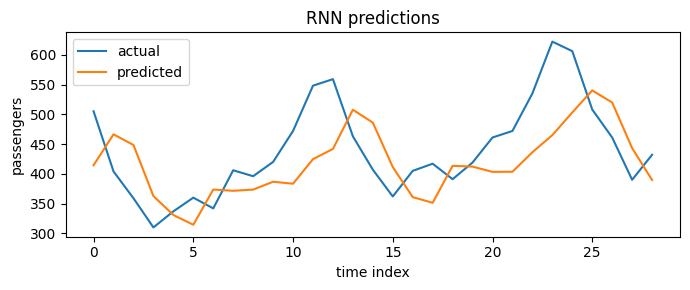

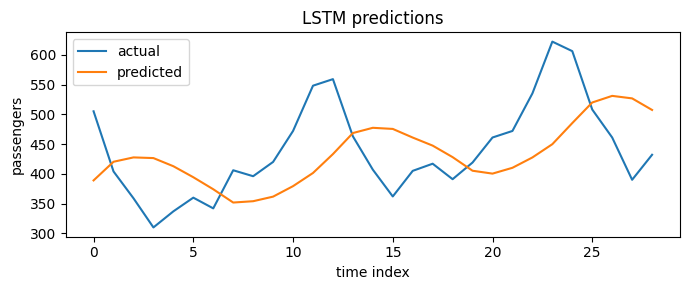

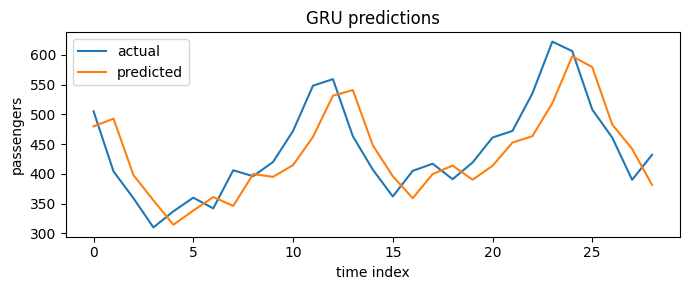

{'rmse_rnn': 70.74278259277344, 'rmse_lstm': 85.109375, 'rmse_gru': 49.507877349853516}


In [32]:
# To-Do: plots and metrics
plot_preds(y_true, yhat_rnn,  'RNN predictions')
plot_preds(y_true, yhat_lstm, 'LSTM predictions')
plot_preds(y_true, yhat_gru,  'GRU predictions')
print({'rmse_rnn': rmse(y_true, yhat_rnn), 'rmse_lstm': rmse(y_true, yhat_lstm), 'rmse_gru': rmse(y_true, yhat_gru)})

**Learning point**
Do not shuffle a univariate time series split. Keep the chronological order. Use early stopping on validation loss to avoid overfitting and reduce training time. For multi-step forecasts, increase the horizon and adapt the output layer size.